# Taller de clustering

 El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

 Para lo cual se debe probar con los diferentes metodos y variables para encontrar el mejor modelo, con su respectiva justificacion y reporte ejecutivo.

---


## Descripción de los datos

El archivo EastWestAirlines contiene la información del programa de viajero frecuente de los pasajeros de una aerolínea. Para cada pasajero los datos incluyen información del historial de millas

Para cada pasajero, los datos incluyen información sobre su historial de millas y sobre las diferentes formas en que acumularon o gastaron millas en el último año. El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

ID# --Unique ID

Balance--Number of miles eligible for award travel

Qual_mile--Number of miles counted as qualifying for Topflight status

cc1_miles -- Number of miles earned with freq. flyer credit card in the past 12 months:

cc2_miles -- Number of miles earned with Rewards credit card in the past 12 months:

cc3_miles -- Number of miles earned with Small Business credit card in the past 12 months:

1 = under 5,000

2 = 5,000 - 10,000

3 = 10,001 - 25,000

4 = 25,001 - 50,000

5 = over 50,000

Bonus_miles--Number of miles earned from non-flight bonus transactions in the past 12 months

Bonus_trans--Number of non-flight bonus transactions in the past 12 months

Flight_miles_12mo--Number of flight miles in the past 12 months

Flight_trans_12--Number of flight transactions in the past 12 months

Days_since_enrolled--Number of days since enrolled in flier program

Award?--whether that person had award flight (free flight) or not


1. Importar librerias

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

2. Cargar base de datos

In [39]:
from google.colab import drive
drive.mount('/content/drive')
datos =pd.read_csv("/content/drive/MyDrive/Aprendizaje no supervisado/EastWestAirlines.csv")
datos.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [40]:
datos.shape
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award              3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


3. Revisar valores nulos

In [41]:
datos.isna().sum()

,0
ID,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


No hay valores nulos

4. Revisar variables

In [42]:
datos.describe()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


como la descripción lo indica el ID es únicamente un identificador y Award muestra si el pasajero tuvo un vuelo gratis.

Por eso no ultilizareninguna de estas dos variables para construir los clusters, ya que el objetivo es encontrar los grupos a partir de las características de los pasajeros.

5. Seleccion de diferentes grupos de variables

Como se pide intentar con diferentes metodos y variables voy a seleccionar diferentes combinaciones de grupos de variables

In [43]:
# Primer grupo variables relacionadas con el uso de millas
variables_millas = [
    'Balance',
    'Qual_miles',
    'Bonus_miles',
    'Flight_miles_12mo'
]

# Segundo grupo variables relacionadas con actividad de vuelos
variables_vuelos = [
    'Balance',
    'Flight_miles_12mo',
    'Flight_trans_12'
]

# Tercer grupo variables relacionadas con tarjetas y bonos
variables_bonos = [
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans'
]

# Cuarto grupo variables de actividad general
variables_actividad = [
    'Balance',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

# quinto grupo todas las variables numéricas relevantes
variables_todas = [
    'Balance',
    'Qual_miles',
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

6. Estandarizar variables

Todas las variables tienen valores muy diferentes, por lo tanto se deben estandarizar

In [44]:
def escalar_datos(datos, variables):

    scaler = StandardScaler()

    X = datos[variables]

    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler

7. K means

voy a encontrar el número adecuado de clusters utilizando el método del codo

K means con variables de millas

In [45]:
X_scaled, scaler = escalar_datos(datos, variables_millas)

In [46]:
#metodo del codo

inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

    print(f"K={k} - Inercia: {kmeans.inertia_}")

K=1 - Inercia: 15996.000000000018
K=2 - Inercia: 12127.819433436773
K=3 - Inercia: 9438.478923923136
K=4 - Inercia: 7538.399129489003
K=5 - Inercia: 6224.115516179666
K=6 - Inercia: 5567.831512504473
K=7 - Inercia: 4937.427081734517
K=8 - Inercia: 4379.625536378887
K=9 - Inercia: 3910.9028722827798
K=10 - Inercia: 3602.3550484477823


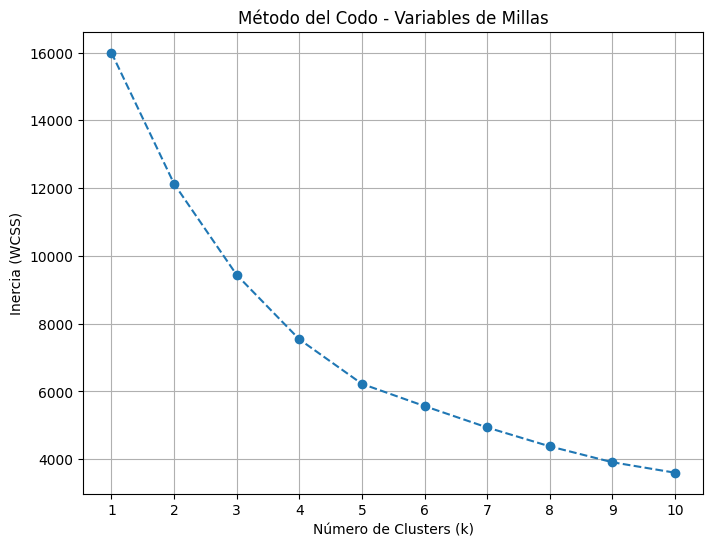

In [47]:
plt.figure(figsize=(8,6))

plt.plot(
    K_range,
    inertia,
    marker='o',
    linestyle='--'
)

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo - Variables de Millas')
plt.xticks(K_range)
plt.grid(True)

plt.show()

8. Silhouette Score para diferentes K

In [48]:
silueta = []

n_cluster = range(2, 10)

for i in n_cluster:

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    score = silhouette_score(
        X_scaled,
        kmeans.labels_
    )

    silueta.append(score)

    print(f"K={i} - Silhouette Score: {score:.4f}")

K=2 - Silhouette Score: 0.6048
K=3 - Silhouette Score: 0.5937
K=4 - Silhouette Score: 0.5637
K=5 - Silhouette Score: 0.5175
K=6 - Silhouette Score: 0.4333
K=7 - Silhouette Score: 0.4450
K=8 - Silhouette Score: 0.4556
K=9 - Silhouette Score: 0.5140


grafico

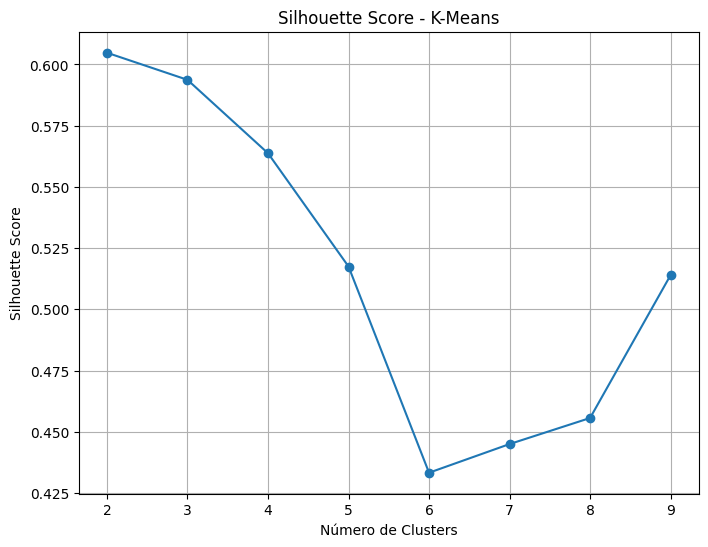

In [49]:
plt.figure(figsize=(8,6))

plt.plot(
    list(n_cluster),
    silueta,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - K-Means')
plt.grid(True)

plt.show()

el silhouette score mas alto esta en 2 clusters

9. Probar K means con diferentes variables

In [50]:
combinaciones = {
    'Variables de millas': variables_millas,
    'Variables de vuelos': variables_vuelos,
    'Variables de bonos': variables_bonos,
    'Variables de actividad': variables_actividad,
    'Todas las variables': variables_todas
}

In [51]:
resultados_kmeans = []

for nombre, variables in combinaciones.items():

    X_scaled, scaler = escalar_datos(datos, variables)

    for k in range(2, 9):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_scaled)

        score = silhouette_score(
            X_scaled,
            labels
        )

        resultados_kmeans.append({
            'Variables': nombre,
            'K': k,
            'Silhouette Score': score,
            'Inercia': kmeans.inertia_
        })

resultados_kmeans = pd.DataFrame(resultados_kmeans)

resultados_kmeans.sort_values(
    'Silhouette Score',
    ascending=False
).head(10)

,Variables,K,Silhouette Score,Inercia
7,Variables de vuelos,2,0.787867,6959.360197
8,Variables de vuelos,3,0.707704,5256.107431
9,Variables de vuelos,4,0.700079,4022.955503
0,Variables de millas,2,0.604773,12127.819433
11,Variables de vuelos,6,0.597518,2694.104301
1,Variables de millas,3,0.593705,9438.478924
10,Variables de vuelos,5,0.588737,3171.759402
16,Variables de bonos,4,0.568451,5833.446962
2,Variables de millas,4,0.563735,7538.399129
15,Variables de bonos,3,0.543656,9403.321530


Entre las combinaciones que intente para K means el grupo que mejor separa a los pasajeros son las 3 variables de vuelos:

variables_vuelos = (
    'Balance',
    'Flight_miles_12mo',
    'Flight_trans_12')

10. Modelo K means seleccionado



In [52]:
mejor_kmeans = resultados_kmeans.loc[
    resultados_kmeans['Silhouette Score'].idxmax()
]

mejor_kmeans

,7
Variables,Variables de vuelos
K,2
Silhouette Score,0.787867
Inercia,6959.360197


In [53]:
nombre_variables = mejor_kmeans['Variables']
k_optimo = int(mejor_kmeans['K'])

variables_optimas = combinaciones[nombre_variables]

X_scaled, scaler = escalar_datos(
    datos,
    variables_optimas
)

kmeans_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_final.fit_predict(X_scaled)

print("Variables utilizadas:", variables_optimas)
print("Número de clusters:", k_optimo)
print("Silhouette Score:", silhouette_score(X_scaled, labels_kmeans))

Variables utilizadas: ['Balance', 'Flight_miles_12mo', 'Flight_trans_12']
Número de clusters: 2
Silhouette Score: 0.7878667431295627


11. Tamaño de los clusters K means

In [54]:
datos_kmeans = datos.copy()

datos_kmeans['Cluster'] = labels_kmeans

datos_kmeans['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3770
1,229


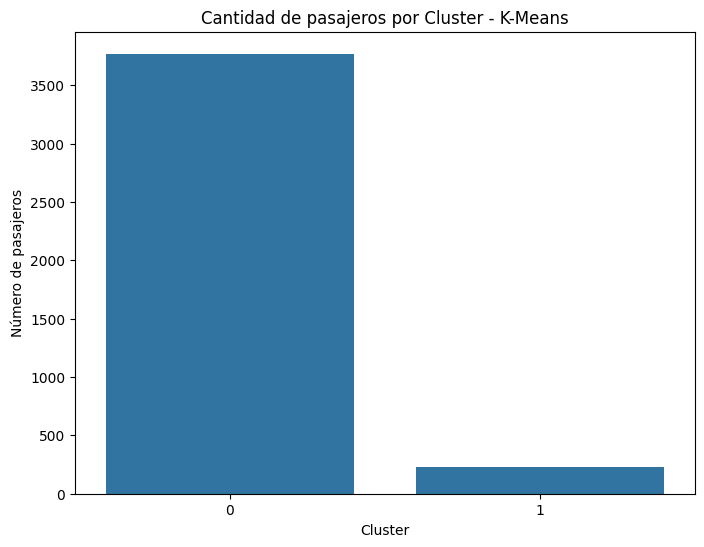

In [55]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=datos_kmeans,
    x='Cluster'
)

plt.title('Cantidad de pasajeros por Cluster - K-Means')
plt.xlabel('Cluster')
plt.ylabel('Número de pasajeros')

plt.show()

Hay una diferencia grande de pasajeros en cada grupo, voy a analizar el perfil de cada cluster, para ver quienes son los [asajeros de cada grupo

In [56]:
perfil_kmeans = datos_kmeans.groupby('Cluster')[
    variables_optimas
].mean()

perfil_kmeans

perfil_kmeans.round(2)

,Balance,Flight_miles_12mo,Flight_trans_12
Cluster,,,
0,65189.75,206.43,0.65
1,212080.15,4635.40,13.34


Aca se puede ver que K-Means identifica dos segmentos muy diferenciados: el Cluster 0 agrupa pasajeros con baja actividad reciente, mientras que el Cluster 1 reúne pasajeros mucho más activos, con mayor cantidad de millas y vuelos realizados. Esto nos puede permite realizar ofertas de millas según el nivel de actividad de cada grupo de pasajeros


12. Clustering jerarquico

Ahora voy a usar este metodo con las mejores variables que se encontraron para K-Means y despues comparar las combinaciones.


In [59]:
X_scaled, scaler = escalar_datos(
    datos,
    variables_millas
)


Probar diferentes numeros de clusters

In [60]:
silueta_hc = []

n_cluster = range(2, 10)

for i in n_cluster:

    jerarquico = AgglomerativeClustering(
        n_clusters=i
    )

    labels = jerarquico.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silueta_hc.append(score)

    print(
        f"Clusters={i} - Silhouette Score: {score:.4f}"
    )

Clusters=2 - Silhouette Score: 0.5460
Clusters=3 - Silhouette Score: 0.5580
Clusters=4 - Silhouette Score: 0.5568
Clusters=5 - Silhouette Score: 0.5428
Clusters=6 - Silhouette Score: 0.5467
Clusters=7 - Silhouette Score: 0.3745
Clusters=8 - Silhouette Score: 0.3876
Clusters=9 - Silhouette Score: 0.3892


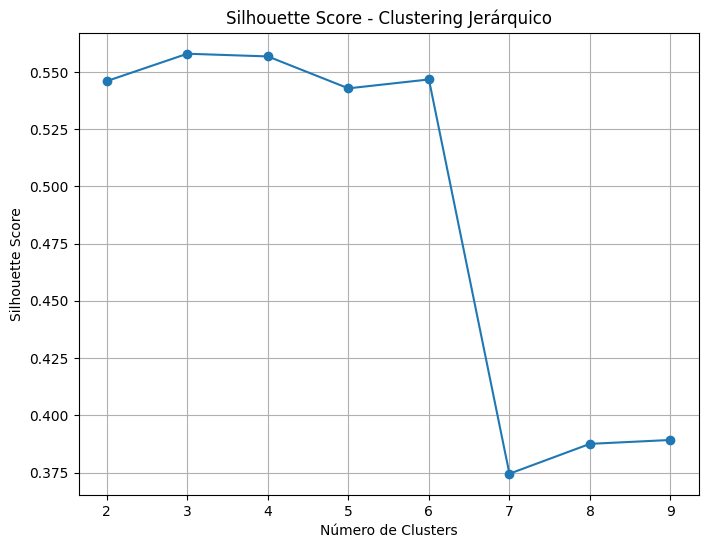

In [61]:
plt.figure(figsize=(8,6))

plt.plot(
    list(n_cluster),
    silueta_hc,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Clustering Jerárquico')
plt.grid(True)

plt.show()

El Silhouette Score indica qué tan bien separados están los grupos y entre más alto, mejor.

En este caso el mejor resultado del clustering jerárquico es:

3 clusters ≈ 0.558

Por lo tanto, para las variables de millas, el clustering jerárquico funciona mejor con 3 clusters

13. Probar clustering jerarquico con diferentes variables

In [62]:
resultados_hc = []

for nombre, variables in combinaciones.items():

    X_scaled, scaler = escalar_datos(
        datos,
        variables
    )

    for k in range(2, 9):

        jerarquico = AgglomerativeClustering(
            n_clusters=k
        )

        labels = jerarquico.fit_predict(X_scaled)

        score = silhouette_score(
            X_scaled,
            labels
        )

        resultados_hc.append({
            'Variables': nombre,
            'Clusters': k,
            'Silhouette Score': score
        })

resultados_hc = pd.DataFrame(
    resultados_hc
)

resultados_hc.sort_values(
    'Silhouette Score',
    ascending=False
).head(10)

,Variables,Clusters,Silhouette Score
7,Variables de vuelos,2,0.808939
8,Variables de vuelos,3,0.622577
9,Variables de vuelos,4,0.614528
11,Variables de vuelos,6,0.614329
12,Variables de vuelos,7,0.613807
10,Variables de vuelos,5,0.612999
15,Variables de bonos,3,0.567230
16,Variables de bonos,4,0.561817
1,Variables de millas,3,0.557954
2,Variables de millas,4,0.556772


14. Mejor modelo jerarquico

In [63]:
mejor_hc = resultados_hc.loc[
    resultados_hc['Silhouette Score'].idxmax()
]

mejor_hc

,7
Variables,Variables de vuelos
Clusters,2
Silhouette Score,0.808939


El clustering jerárquico obtuvo su mejor resultado utilizando las variables de vuelos y 2 clusters con un Silhouette Score de 0.809 esto indica una buena separación entre los grupos

15. DBSCAN

ahora voy a probar el tercer metodo

Para DBSCAN vamos a probar diferentes valores de eps y min_samples ya que este metodo encuentra los grupos dependiendo de los parametros.

Epsilon (ε): define qué tan cerca deben estar dos pasajeros para considerarse vecinos.

MinPts: define cuántos pasajeros debe haber cerca para considerar que existe una zona suficientemente densa para formar un grupo.

In [64]:
resultados_dbscan = []

eps_values = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.1,
    1.2
]

minPts_values = [
    3,
    5,
    10
]

In [65]:
for nombre, variables in combinaciones.items():

    X_scaled, scaler = escalar_datos(
        datos,
        variables
    )

    for minPts in minPts_values:

        for eps in eps_values:

            dbscan_model = DBSCAN(
                eps=eps,
                min_samples=minPts
            )

            labels = dbscan_model.fit_predict(
                X_scaled
            )

            # Número de clusters sin contar ruido
            unique_labels = set(labels)

            unique_labels.discard(-1)

            num_clusters = len(unique_labels)

            # Calcular silhouette solamente cuando existen al menos 2 clusters
            if num_clusters >= 2:

                mask = labels != -1

                if len(set(labels[mask])) >= 2:

                    score = silhouette_score(
                        X_scaled[mask],
                        labels[mask]
                    )

                else:
                    score = np.nan

            else:
                score = np.nan

            resultados_dbscan.append({
                'Variables': nombre,
                'Epsilon': eps,
                'MinPts': minPts,
                'Numero de clusters': num_clusters,
                'Silhouette Score': score,
                'Puntos ruido': sum(labels == -1)
            })

resultados_dbscan = pd.DataFrame(
    resultados_dbscan
)

In [66]:
resultados_dbscan.sort_values(
    'Silhouette Score',
    ascending=False
).head(10)

,Variables,Epsilon,MinPts,Numero de clusters,Silhouette Score,Puntos ruido
46,Variables de vuelos,0.9,5,2,0.846054,73
48,Variables de vuelos,1.1,5,2,0.843829,51
47,Variables de vuelos,1.0,5,2,0.843534,67
36,Variables de vuelos,0.9,3,4,0.809580,55
39,Variables de vuelos,1.2,3,2,0.776012,35
85,Variables de bonos,0.8,10,3,0.737699,61
86,Variables de bonos,0.9,10,3,0.735324,48
65,Variables de bonos,0.8,3,3,0.734305,46
75,Variables de bonos,0.8,5,3,0.734305,46
88,Variables de bonos,1.1,10,3,0.734018,40


El mejor resultado fue con ε=0.9 y MinPts=5 logrando un Silhouette Score de 0.846 con 2 clusters y superando a K-Means y al clustering jerárquico.

16. Comparacion de los tres modelos



In [67]:
mejor_kmeans = resultados_kmeans.loc[
    resultados_kmeans['Silhouette Score'].idxmax()
]

mejor_hc = resultados_hc.loc[
    resultados_hc['Silhouette Score'].idxmax()
]

mejor_dbscan = resultados_dbscan.loc[
    resultados_dbscan['Silhouette Score'].idxmax()
]

comparacion = pd.DataFrame({
    'Método': [
        'K-Means',
        'Clustering Jerárquico',
        'DBSCAN'
    ],

    'Variables': [
        mejor_kmeans['Variables'],
        mejor_hc['Variables'],
        mejor_dbscan['Variables']
    ],

    'Número de clusters': [
        mejor_kmeans['K'],
        mejor_hc['Clusters'],
        mejor_dbscan['Numero de clusters']
    ],

    'Silhouette Score': [
        mejor_kmeans['Silhouette Score'],
        mejor_hc['Silhouette Score'],
        mejor_dbscan['Silhouette Score']
    ]
})

comparacion.sort_values(
    'Silhouette Score',
    ascending=False
)

,Método,Variables,Número de clusters,Silhouette Score
2,DBSCAN,Variables de vuelos,2,0.846054
1,Clustering Jerárquico,Variables de vuelos,2,0.808939
0,K-Means,Variables de vuelos,2,0.787867


El mejor modelo es DBSCAN porque obtuvo el mayor Silhouette Score (0.846054) y 2 clusters.

Por lo tanto se selecciona este modelo como el más adecuado para segmentar los pasajeros según su actividad de vuelos.

17. Modelo final



In [74]:
nombre_variables = mejor_modelo['Variables']
variables_finales = combinaciones[nombre_variables]

X_final, scaler_final = escalar_datos(
    datos,
    variables_finales
)

eps_final = mejor_dbscan['Epsilon']
minPts_final = int(mejor_dbscan['MinPts'])

modelo_final = DBSCAN(
    eps=eps_final,
    min_samples=minPts_final
)

labels_final = modelo_final.fit_predict(X_final)

18. perfil final de los pasajeros

asignar a cada pasajero su respectivo cluster

In [75]:
datos_final = datos.copy()

datos_final['Cluster'] = labels_final

# Cantidad de pasajeros por cluster
datos_final['Cluster'].value_counts().sort_index()

,count
Cluster,
-1,73
0,3917
1,9


DBSCAN identificó 2 clusters de pasajeros y 73 outliers o valores atipicos

In [78]:
perfil_final = datos_final.groupby(
    'Cluster'
)[variables_finales].mean()

perfil_final.round(2)

,Balance,Flight_miles_12mo,Flight_trans_12
Cluster,,,
-1,343549.75,6928.15,18.85
0,68414.44,323.25,1.00
1,141469.44,7538.00,24.00


Comparar con award

In [80]:
award_por_cluster = datos_final.groupby(
    'Cluster'
)['Award'].mean() * 100

award_por_cluster.round(2)

,Award
Cluster,
-1,83.56
0,36.02
1,100.00


Conclusion

El modelo DBSCAN identifico dos segmentos diferenciados. El Cluster 0 representa la mayoría de los pasajeros y muestra un bajo nivel de actividad, mientras que el Cluster 1 aunque es pequeño, agrupa pasajeros mucho más activos, con mayor balance, más millas y mayor frecuencia de vuelos, y presenta un 100% de uso de vuelos premio. Los 73 outliers corresponden a pasajeros con comportamientos extremos y también presentan un alto uso de vuelos premio.


Cluster 0 :segmento masivo y menor actividad: se podrían ofrecer incentivos para aumentar el uso de la tarjeta y acumular más millas, pueden ser bonos por alcanzar cierto número de vuelos o promociones de millas adicionales.

Cluster 1 : pasajeros muy activos, como ya tienen un uso muy alto, puede ser una oportunidad ofrecer beneficios premium o recompensas por fidelización, en lugar de incentivos básicos como al otro grupo

Outliers : clientes de comportamiento extremo, seria bueno analizarlos aparte porque son pocos y tienen un comportamiento muy diferente

